# Sprint 2 — Configuração de Ambiente e EDA de Hounsfield Units

Configuração do ambiente de trabalho e análise exploratória da escala de Hounsfield Units (HU) em imagens de tomografia computadorizada do dataset **LIDC-IDRI** (TCIA), como base para as próximas etapas do pipeline de detecção de nódulos pulmonares.

**Dataset:** LIDC-IDRI (manifest `TCIA_LIDC-IDRI_20200921.tcia`)  
**Seed fixa:** 42 (reprodutibilidade)

## 1. Instalação e imports

In [1]:
# Ambiente local (VSCode): dependencias fixadas em requirements.txt
# pip install -r requirements.txt
import numpy, matplotlib, pydicom, SimpleITK, sklearn, requests  # sanity check dos imports


In [2]:
import os
import io
import zipfile
import random
import time

import requests
import numpy as np
import pydicom
import SimpleITK as sitk
import matplotlib.pyplot as plt

## 2. Reprodutibilidade

Fixamos a seed para garantir que qualquer etapa aleatória do pipeline (amostragem, splits, etc.) seja reprodutível entre execuções.

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

## 3. Seleção e download dos dados

O manifest do TCIA lista séries de diferentes modalidades (CT, DX, anotações), não apenas tomografias. Por isso, filtramos explicitamente por `Modality == "CT"` via API REST do TCIA antes de baixar qualquer série, evitando baixar imagens fora do escopo do projeto (ex: radiografias digitais isoladas presentes na mesma coleção).

In [4]:
# Extrair os SeriesInstanceUID do manifest
MANIFEST_PATH = 'TCIA_LIDC-IDRI_20200921.tcia'  # caminho relativo, na raiz do repositorio
with open(MANIFEST_PATH) as f:
    linhas = f.readlines()

uids = [l.strip() for l in linhas if l.strip().startswith('1.3.6.1.4.1')]
print(f"Total de series no manifest: {len(uids)}")

Total de series no manifest: 1308


In [5]:
# Filtrar apenas series de CT (checando metadados sem baixar as imagens)
url_meta = 'https://services.cancerimagingarchive.net/nbia-api/services/v1/getSeriesMetaData'

def filtrar_series_ct(lista_uids, limite=20):
    series_ct = []
    for uid in lista_uids[:limite]:
        try:
            resp = requests.get(url_meta, params={'SeriesInstanceUID': uid}, timeout=30)
        except requests.exceptions.RequestException as e:
            print(f"  aviso: falha ao consultar {uid[:20]}...: {e}")
            continue
        if resp.status_code == 200:
            dados = resp.json()
            if dados and dados[0].get('Modality') == 'CT':
                series_ct.append(uid)
        time.sleep(0.2)  # evita rate limit da API
    return series_ct

series_ct = filtrar_series_ct(uids, limite=20)
print(f"Series CT encontradas: {len(series_ct)}")

Series CT encontradas: 10


In [6]:
# Baixar a primeira serie CT confirmada
url_img = 'https://services.cancerimagingarchive.net/nbia-api/services/v1/getImage'
resp = requests.get(url_img, params={'SeriesInstanceUID': series_ct[0]}, timeout=60)

PASTA_SERIE = 'data/serie_ct'  # pasta local (ignorada no git via .gitignore)
os.makedirs(PASTA_SERIE, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall(PASTA_SERIE)

print(f"Arquivos DICOM baixados: {len(os.listdir(PASTA_SERIE))}")

Arquivos DICOM baixados: 134


## 4. Carregamento e conversão para Hounsfield Units

A conversão de valores brutos de pixel para HU segue a fórmula:

$$HU = pixel \times RescaleSlope + RescaleIntercept$$

Ao carregar a série completa com `SimpleITK.ImageSeriesReader`, essa conversão já é aplicada automaticamente a partir dos metadados de cada arquivo DICOM.

In [7]:
leitor = sitk.ImageSeriesReader()
dicom_ids = leitor.GetGDCMSeriesFileNames(PASTA_SERIE)
leitor.SetFileNames(dicom_ids)
volume = leitor.Execute()

volume_array = sitk.GetArrayFromImage(volume)
print("Formato do volume (fatias, altura, largura):", volume_array.shape)
print("Mínimo HU:", volume_array.min())
print("Máximo HU:", volume_array.max())

Formato do volume (fatias, altura, largura): (133, 512, 512)
Mínimo HU: -2048
Máximo HU: 3071


## 5. Histograma e visualização

O volume contém um valor de **padding (-2048 HU)** correspondente aos pixels fora do campo de visão circular (FOV) do scanner, comum em reconstruções de CT dentro de uma matriz quadrada. Esse valor não representa tecido real e é filtrado antes da análise de distribuição de HU.

In [8]:
n_padding = np.sum(volume_array == -2048)
total = volume_array.size
print(f"Pixels de padding (-2048 HU): {n_padding} ({100*n_padding/total:.2f}% do volume)")

Pixels de padding (-2048 HU): 7417676 (21.28% do volume)


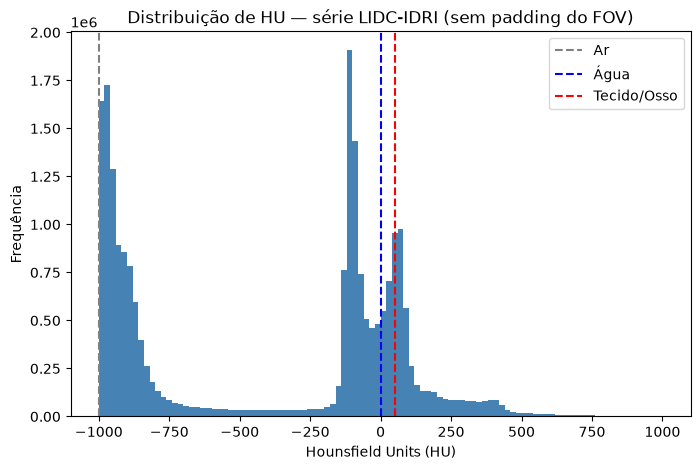

In [9]:
mascara_valida = volume_array > -1500  # remove o pico artificial de padding

plt.figure(figsize=(8, 5))
plt.hist(volume_array[mascara_valida].flatten(), bins=100, range=(-1000, 1000), color='steelblue')
plt.xlabel('Hounsfield Units (HU)')
plt.ylabel('Frequência')
plt.title('Distribuição de HU — série LIDC-IDRI (sem padding do FOV)')
plt.axvline(-1000, color='gray', linestyle='--', label='Ar')
plt.axvline(0, color='blue', linestyle='--', label='Água')
plt.axvline(50, color='red', linestyle='--', label='Tecido/Osso')
plt.legend()
plt.show()

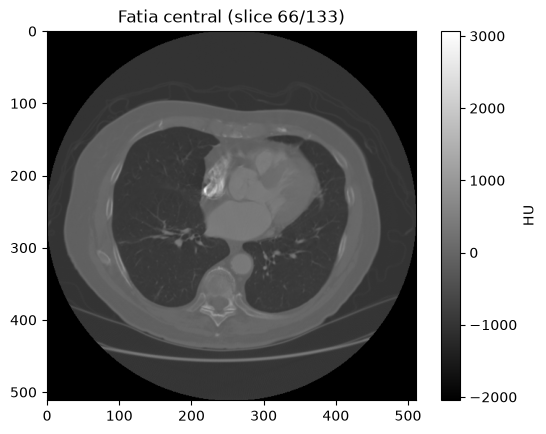

In [10]:
meio = volume_array.shape[0] // 2
plt.imshow(volume_array[meio], cmap='gray')
plt.colorbar(label='HU')
plt.title(f'Fatia central (slice {meio}/{volume_array.shape[0]})')
plt.show()

## 6. Conclusões da EDA

- O manifest do TCIA contém séries de modalidades distintas (CT, DX, anotações); foi necessário filtrar explicitamente por `Modality == "CT"` antes do download.
- A série de CT selecionada tem 133 fatias, resolução 512x512, com `RescaleSlope=1` e `RescaleIntercept=-1024` — valores típicos de CT.
- O histograma mostra dois picos principais: um grande próximo a **-1000 HU** (ar nos pulmões) e outro próximo a **0-50 HU** (tecidos moles/água), com uma cauda de densidades mais altas (gordura, estruturas ósseas).
- Aproximadamente **21% do volume** corresponde a valores de padding (-2048 HU), referentes a pixels fora do campo de visão circular do scanner — esse valor deve ser tratado (mascarado ou excluído) em etapas futuras de pré-processamento e modelagem.

## 7. Faixa de HU do pulmão e threshold de baseline

O tecido pulmonar aparece na escala HU aproximadamente entre **-700 e -500 HU** — valores intermediários entre o ar puro (-1000 HU) e os tecidos moles (0-50 HU), já que o pulmão é uma mistura de ar (alvéolos) com uma pequena quantidade de tecido (paredes alveolares, vasos).

Marcamos essa faixa no histograma para confirmar visualmente onde ela se encontra em relação aos outros picos, e usamos isso como ponto de partida para um **threshold de baseline** de segmentação pulmonar.

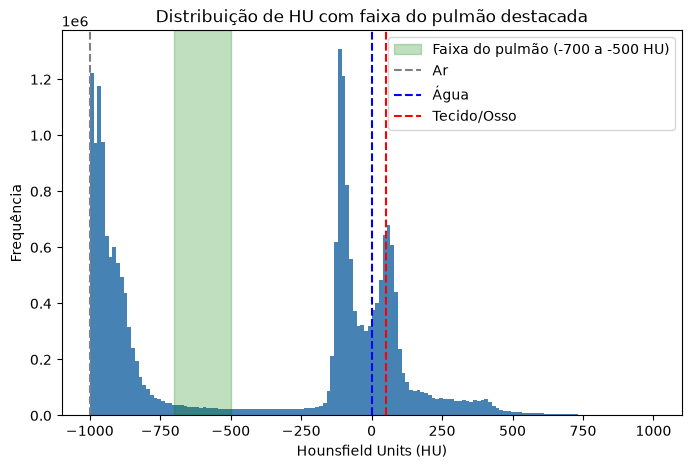

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(volume_array[mascara_valida].flatten(), bins=150, range=(-1000, 1000), color='steelblue')

# Faixa do pulmão destacada
plt.axvspan(-700, -500, color='green', alpha=0.25, label='Faixa do pulmão (-700 a -500 HU)')

plt.axvline(-1000, color='gray', linestyle='--', label='Ar')
plt.axvline(0, color='blue', linestyle='--', label='Água')
plt.axvline(50, color='red', linestyle='--', label='Tecido/Osso')

plt.xlabel('Hounsfield Units (HU)')
plt.ylabel('Frequência')
plt.title('Distribuição de HU com faixa do pulmão destacada')
plt.legend()
plt.show()

In [12]:
# Threshold de baseline para segmentação pulmonar
# Pulmão: ar dentro do tecido pulmonar, tipicamente entre -1000 e -500 HU
LIMIAR_INFERIOR = -1000
LIMIAR_SUPERIOR = -500

mascara_pulmao = (volume_array > LIMIAR_INFERIOR) & (volume_array < LIMIAR_SUPERIOR)

pixels_pulmao = np.sum(mascara_pulmao)
total_pixels = volume_array.size
print(f"Pixels dentro da faixa pulmonar: {pixels_pulmao} ({100*pixels_pulmao/total_pixels:.2f}% do volume)")

Pixels dentro da faixa pulmonar: 9400920 (26.96% do volume)


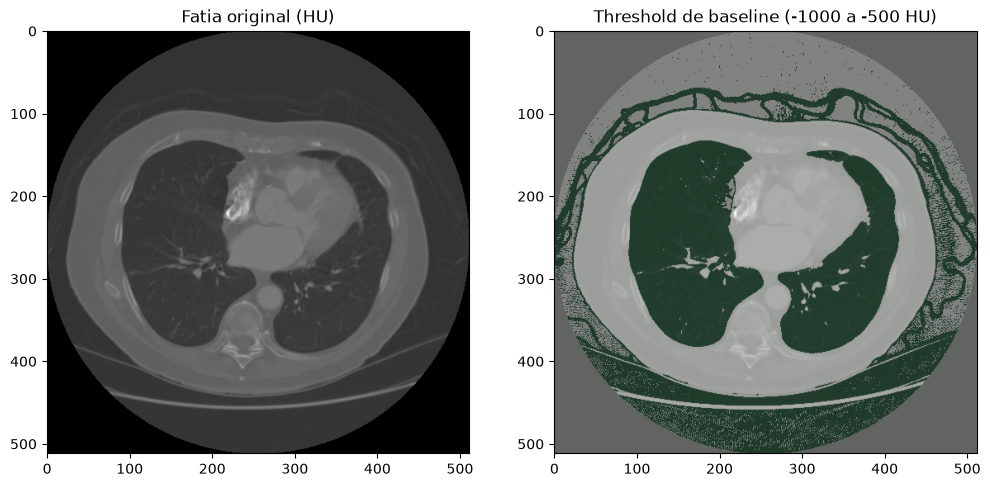

In [13]:
# Visualizar a máscara de baseline sobre a fatia central
meio = volume_array.shape[0] // 2

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(volume_array[meio], cmap='gray')
ax[0].set_title('Fatia original (HU)')

ax[1].imshow(volume_array[meio], cmap='gray')
ax[1].imshow(mascara_pulmao[meio], cmap='Greens', alpha=0.4)
ax[1].set_title('Threshold de baseline (-1000 a -500 HU)')
plt.show()

**Observações sobre o threshold de baseline:**

- Esse threshold simples (`-1000 < HU < -500`) captura a região de ar/pulmão, mas também pode incluir ar externo ao corpo (fora do paciente) e ar em outras cavidades (ex: intestino, se presente na fatia).
- Por isso, esse é apenas um **baseline** — etapas futuras do pipeline devem combinar esse threshold com operações morfológicas (erosão/dilatação) ou detecção de componentes conectados para isolar apenas a região pulmonar real, descartando ar externo ao corpo.
- A faixa -700 a -500 HU citada na tarefa é o ponto de corte típico do **tecido pulmonar** propriamente dito (mistura ar+tecido); usamos até -1000 no threshold porque o interior do pulmão pode chegar bem perto do ar puro nas regiões mais aeradas.